In [1]:
# ============================================
# HEDGELAB - OPTIONS RISK & HEDGING ANALYSIS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from math import log, sqrt, exp

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ============================================
# 1. PORTFOLIO & MARKET INPUTS
# ============================================

# Stock / portfolio
S = 200.0                 # Current stock price
shares = 1000             # Number of shares held

# Option
K = 195.0                 # Put option strike price
T = 30 / 365              # Time to expiry (30 days)

# Market assumptions
sigma = 0.25              # Annualized volatility = 25%
r = 0.05                  # Risk-free interest rate = 5%

# Option contract specification
contract_size = 100       # 1 option contract = 100 shares

print("Portfolio value:", f"${S * shares:,.2f}")
print("Stock price:", f"${S:.2f}")
print("Shares held:", shares)
print("Put strike:", f"${K:.2f}")
print("Days to expiry:", 30)
print("Volatility:", f"{sigma * 100:.1f}%")
print("Risk-free rate:", f"{r * 100:.1f}%")

Portfolio value: $200,000.00
Stock price: $200.00
Shares held: 1000
Put strike: $195.00
Days to expiry: 30
Volatility: 25.0%
Risk-free rate: 5.0%


In [3]:
# ============================================
# 2. BLACK-SCHOLES OPTION PRICING
# ============================================

def black_scholes(S, K, T, r, sigma, option_type="call"):

    if T <= 0:
        if option_type == "call":
            return max(S - K, 0)
        else:
            return max(K - S, 0)

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = (
            S * norm.cdf(d1)
            - K * np.exp(-r * T) * norm.cdf(d2)
        )
    else:
        price = (
            K * np.exp(-r * T) * norm.cdf(-d2)
            - S * norm.cdf(-d1)
        )

    return price


call_price = black_scholes(
    S, K, T, r, sigma, "call"
)

put_price = black_scholes(
    S, K, T, r, sigma, "put"
)

print("European Call Price:", f"${call_price:.2f}")
print("European Put Price :", f"${put_price:.2f}")

European Call Price: $9.00
European Put Price : $3.20


In [4]:
# ============================================
# 3. OPTION GREEKS
# ============================================

def calculate_greeks(S, K, T, r, sigma, option_type="put"):

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    pdf_d1 = norm.pdf(d1)

    # Delta
    if option_type == "call":
        delta = norm.cdf(d1)
    else:
        delta = norm.cdf(d1) - 1

    # Gamma
    gamma = pdf_d1 / (
        S * sigma * np.sqrt(T)
    )

    # Vega
    vega = S * pdf_d1 * np.sqrt(T)

    # Theta
    if option_type == "call":

        theta = (
            -(S * pdf_d1 * sigma) /
            (2 * np.sqrt(T))
            - r * K * np.exp(-r * T) * norm.cdf(d2)
        )

    else:

        theta = (
            -(S * pdf_d1 * sigma) /
            (2 * np.sqrt(T))
            + r * K * np.exp(-r * T) * norm.cdf(-d2)
        )

    # Rho
    if option_type == "call":
        rho = (
            K * T * np.exp(-r * T) * norm.cdf(d2)
        )
    else:
        rho = (
            -K * T * np.exp(-r * T) * norm.cdf(-d2)
        )

    return {
        "Delta": delta,
        "Gamma": gamma,
        "Vega": vega,
        "Theta": theta,
        "Rho": rho
    }


greeks = calculate_greeks(
    S, K, T, r, sigma, "put"
)

greeks_df = pd.DataFrame(
    greeks.items(),
    columns=["Greek", "Value"]
)

greeks_df

,Greek,Value
0,Delta,-0.327648
1,Gamma,0.025191
2,Vega,20.705205
3,Theta,-28.052543
4,Rho,-5.649243


In [5]:
# ============================================
# 4. PORTFOLIO DELTA & HEDGE REQUIREMENT
# ============================================

stock_delta = shares

put_delta = greeks["Delta"]

# Number of option contracts required
# to approximately offset the stock delta
hedge_contracts = abs(
    stock_delta /
    (put_delta * contract_size)
)

print("Stock Portfolio Delta:", f"{stock_delta:.2f}")
print("Put Option Delta:", f"{put_delta:.4f}")
print(
    "Estimated Hedge Contracts:",
    f"{hedge_contracts:.2f}"
)

print(
    "\nInterpretation:"
)

print(
    f"A put option has a delta of {put_delta:.4f}, "
    f"so approximately {hedge_contracts:.2f} contracts "
    "would be required for a near delta-neutral hedge."
)

Stock Portfolio Delta: 1000.00
Put Option Delta: -0.3276
Estimated Hedge Contracts: 30.52

Interpretation:
A put option has a delta of -0.3276, so approximately 30.52 contracts would be required for a near delta-neutral hedge.


In [8]:
# ============================================
# 5. SCENARIO ANALYSIS - CORRECTED
# ============================================

# Initial cost of the protective put
initial_put_price = put_price

initial_hedge_cost = (
    initial_put_price
    * hedge_contracts
    * contract_size
)

scenario_results = []

for _, row in scenarios.iterrows():

    scenario_price = row["Stock Price"]
    scenario_vol = row["Volatility"]

    # ----------------------------------------
    # UNHEDGED PORTFOLIO
    # ----------------------------------------

    stock_value = scenario_price * shares

    initial_stock_value = S * shares

    unhedged_pnl = (
        stock_value - initial_stock_value
    )

    # ----------------------------------------
    # PROTECTIVE PUT
    # ----------------------------------------

    new_put_price = black_scholes(
        scenario_price,
        K,
        T,
        r,
        scenario_vol,
        "put"
    )

    # Current value of all put contracts
    hedge_value = (
        new_put_price
        * hedge_contracts
        * contract_size
    )

    # Hedge P&L = current value - initial premium
    hedge_pnl = (
        hedge_value - initial_hedge_cost
    )

    # ----------------------------------------
    # HEDGED PORTFOLIO
    # ----------------------------------------

    hedged_pnl = (
        unhedged_pnl + hedge_pnl
    )

    scenario_results.append({
        "Scenario": row["Scenario"],
        "Stock Price": scenario_price,
        "Volatility": scenario_vol,
        "Unhedged P&L": unhedged_pnl,
        "Hedge P&L": hedge_pnl,
        "Hedged P&L": hedged_pnl
    })


scenario_df = pd.DataFrame(
    scenario_results
)

scenario_df

,Scenario,Stock Price,Volatility,Unhedged P&L,Hedge P&L,Hedged P&L
0,Strong Rally,230.0,0.22,30000.0,-9729.450913,20270.549087
1,Moderate Rally,210.0,0.24,10000.0,-7071.591227,2928.408773
2,Base Case,200.0,0.25,0.0,0.000000,0.000000
3,Moderate Drop,180.0,0.30,-20000.0,38647.694895,18647.694895
4,Market Crash,150.0,0.45,-50000.0,125693.407480,75693.407480


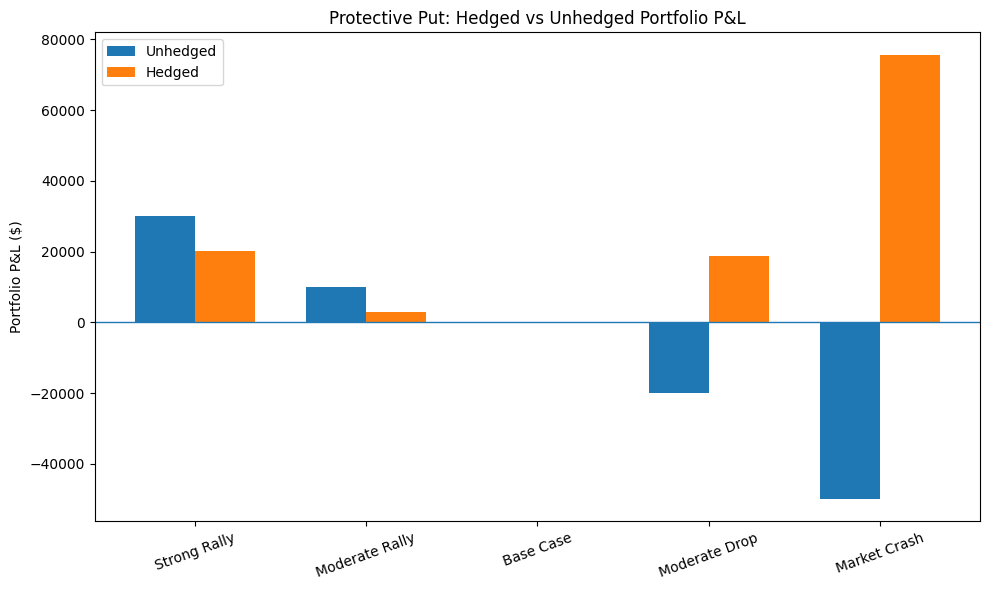

In [9]:
# ============================================
# 6. HEDGED VS UNHEDGED PERFORMANCE
# ============================================

x = np.arange(len(scenario_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    scenario_df["Unhedged P&L"],
    width,
    label="Unhedged"
)

plt.bar(
    x + width/2,
    scenario_df["Hedged P&L"],
    width,
    label="Hedged"
)

plt.axhline(0, linewidth=1)

plt.xticks(
    x,
    scenario_df["Scenario"],
    rotation=20
)

plt.ylabel("Portfolio P&L ($)")
plt.title(
    "Protective Put: Hedged vs Unhedged Portfolio P&L"
)

plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# ============================================
# 7. MONTE CARLO SIMULATION
# ============================================

np.random.seed(42)

# Simulation settings
simulations = 10000
days = 30
dt = 1 / 365

# Generate random daily returns using GBM
random_shocks = np.random.normal(
    0,
    1,
    (simulations, days)
)

daily_returns = (
    (r - 0.5 * sigma**2) * dt
    + sigma * np.sqrt(dt) * random_shocks
)

# Simulated price paths
price_paths = S * np.exp(
    np.cumsum(daily_returns, axis=1)
)

# Final stock prices after 30 days
final_prices = price_paths[:, -1]

print("Number of simulations:", simulations)
print("Simulation horizon:", days, "days")
print(
    "Average simulated final price:",
    f"${final_prices.mean():.2f}"
)
print(
    "Minimum simulated price:",
    f"${final_prices.min():.2f}"
)
print(
    "Maximum simulated price:",
    f"${final_prices.max():.2f}"
)

Number of simulations: 10000
Simulation horizon: 30 days
Average simulated final price: $200.84
Minimum simulated price: $156.21
Maximum simulated price: $268.14


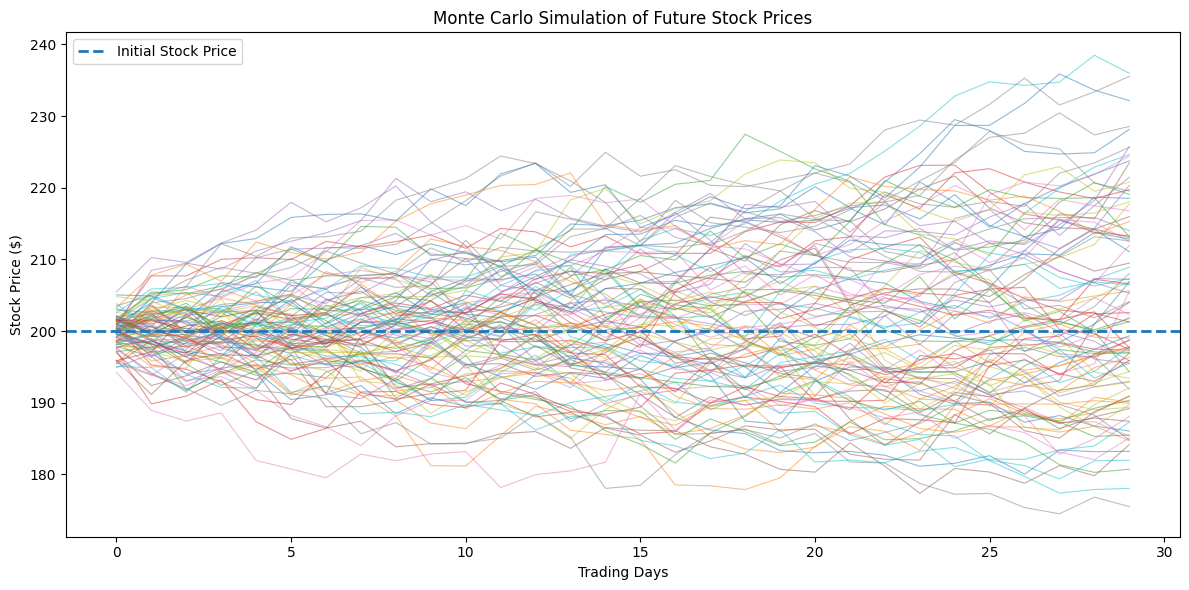

In [11]:
# ============================================
# 8. SIMULATED STOCK PRICE PATHS
# ============================================

plt.figure(figsize=(12, 6))

# Plot only 100 paths so the chart remains readable
plt.plot(
    price_paths[:100].T,
    linewidth=0.8,
    alpha=0.5
)

plt.axhline(
    S,
    linestyle="--",
    linewidth=2,
    label="Initial Stock Price"
)

plt.xlabel("Trading Days")
plt.ylabel("Stock Price ($)")
plt.title(
    "Monte Carlo Simulation of Future Stock Prices"
)

plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# ============================================
# 9. PORTFOLIO P&L AT OPTION EXPIRY
# ============================================

# Unhedged stock portfolio P&L
unhedged_pnl = (
    (final_prices - S) * shares
)

# Protective put payoff at expiry
put_payoff = np.maximum(
    K - final_prices,
    0
)

# Total payoff from all put contracts
total_put_payoff = (
    put_payoff
    * hedge_contracts
    * contract_size
)

# Initial cost of buying the put
initial_hedge_cost = (
    put_price
    * hedge_contracts
    * contract_size
)

# Hedged portfolio P&L
hedged_pnl = (
    unhedged_pnl
    + total_put_payoff
    - initial_hedge_cost
)

results = pd.DataFrame({
    "Final Stock Price": final_prices,
    "Unhedged P&L": unhedged_pnl,
    "Put Payoff": total_put_payoff,
    "Hedged P&L": hedged_pnl
})

results.head()

,Final Stock Price,Unhedged P&L,Put Payoff,Hedged P&L
0,186.046757,-13953.243203,27325.773498,3597.432208
1,191.003922,-8996.078197,12196.242771,-6574.933513
2,201.324213,1324.213499,0.000000,-8450.884588
3,198.722290,-1277.709871,0.000000,-11052.807958
4,192.978918,-7021.081870,6168.449148,-10627.730810


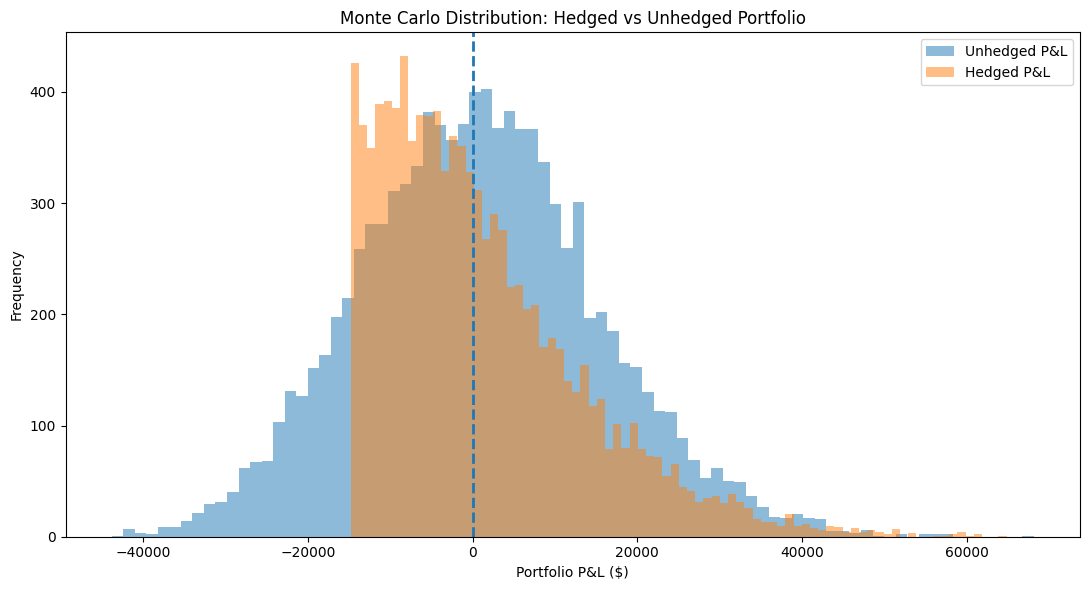

In [13]:
# ============================================
# 10. RISK DISTRIBUTION
# ============================================

plt.figure(figsize=(11, 6))

plt.hist(
    unhedged_pnl,
    bins=80,
    alpha=0.5,
    label="Unhedged P&L"
)

plt.hist(
    hedged_pnl,
    bins=80,
    alpha=0.5,
    label="Hedged P&L"
)

plt.axvline(
    0,
    linewidth=2,
    linestyle="--"
)

plt.xlabel("Portfolio P&L ($)")
plt.ylabel("Frequency")
plt.title(
    "Monte Carlo Distribution: Hedged vs Unhedged Portfolio"
)

plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# ============================================
# 11. RISK METRICS
# ============================================

def calculate_risk_metrics(pnl):

    return {
        "Mean P&L": pnl.mean(),
        "Median P&L": np.median(pnl),
        "Worst Case": pnl.min(),
        "5th Percentile": np.percentile(pnl, 5),
        "1st Percentile": np.percentile(pnl, 1),
        "Probability of Loss": np.mean(pnl < 0) * 100
    }


unhedged_metrics = calculate_risk_metrics(
    unhedged_pnl
)

hedged_metrics = calculate_risk_metrics(
    hedged_pnl
)

risk_comparison = pd.DataFrame({
    "Metric": list(unhedged_metrics.keys()),
    "Unhedged": list(unhedged_metrics.values()),
    "Hedged": list(hedged_metrics.values())
})

risk_comparison

,Metric,Unhedged,Hedged
0,Mean P&L,844.275073,1044.638785
1,Median P&L,606.481104,-1653.721051
2,Worst Case,-43792.808709,-14773.860697
3,5th Percentile,-22410.926919,-13576.464854
4,1st Percentile,-31038.825271,-14551.919444
5,Probability of Loss,48.360000,55.640000


In [15]:
# ============================================
# 12. FINAL RISK SUMMARY
# ============================================

print("=" * 55)
print("HEDGELAB - PORTFOLIO RISK SUMMARY")
print("=" * 55)

print(f"\nInitial Stock Price      : ${S:.2f}")
print(f"Shares Held              : {shares:,}")
print(f"Initial Portfolio Value  : ${S * shares:,.2f}")

print(f"\nProtective Put Strike    : ${K:.2f}")
print(f"Put Premium              : ${put_price:.2f}")
print(f"Hedge Contracts          : {hedge_contracts:.2f}")

print("\n--- RISK COMPARISON ---")

print(
    f"\nUnhedged 5th Percentile : "
    f"${unhedged_metrics['5th Percentile']:,.2f}"
)

print(
    f"Hedged 5th Percentile   : "
    f"${hedged_metrics['5th Percentile']:,.2f}"
)

print(
    f"\nUnhedged Worst Case     : "
    f"${unhedged_metrics['Worst Case']:,.2f}"
)

print(
    f"Hedged Worst Case       : "
    f"${hedged_metrics['Worst Case']:,.2f}"
)

print(
    f"\nUnhedged Probability of Loss : "
    f"{unhedged_metrics['Probability of Loss']:.2f}%"
)

print(
    f"Hedged Probability of Loss   : "
    f"{hedged_metrics['Probability of Loss']:.2f}%"
)

print("\n" + "=" * 55)
print("CONCLUSION")
print("=" * 55)

print(
    "\nThe protective put reduces downside exposure "
    "by converting part of the portfolio's negative "
    "tail risk into a known hedging cost."
)

print(
    "The trade-off is that the hedge reduces upside "
    "performance because the option premium is paid upfront."
)

HEDGELAB - PORTFOLIO RISK SUMMARY

Initial Stock Price      : $200.00
Shares Held              : 1,000
Initial Portfolio Value  : $200,000.00

Protective Put Strike    : $195.00
Put Premium              : $3.20
Hedge Contracts          : 30.52

--- RISK COMPARISON ---

Unhedged 5th Percentile : $-22,410.93
Hedged 5th Percentile   : $-13,576.46

Unhedged Worst Case     : $-43,792.81
Hedged Worst Case       : $-14,773.86

Unhedged Probability of Loss : 48.36%
Hedged Probability of Loss   : 55.64%

CONCLUSION

The protective put reduces downside exposure by converting part of the portfolio's negative tail risk into a known hedging cost.
The trade-off is that the hedge reduces upside performance because the option premium is paid upfront.
